In [324]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import sklearn
import pmdarima
from sktime.forecasting.arima import AutoARIMA, ARIMA
from sktime.forecasting.base import ForecastingHorizon
from sktime.utils.plotting import plot_correlations
from sktime.performance_metrics.forecasting import mean_absolute_scaled_error,mean_absolute_percentage_error

In [325]:
data = pd.read_csv('parkingLot.csv')

In [326]:
entry_data = data[data['camera_id'] == 1]
print(entry_data.shape)

(53347, 3)


In [327]:
# Convert the 'timestamp' column to datetime
entry_data['timestamp'] = pd.to_datetime(entry_data['timestamp'])
print(entry_data.shape)

# Extract the date part from the timestamp and group by the date to count the number of vehicles
cars_per_date = entry_data.groupby(entry_data['timestamp'].dt.date).size().reset_index(name='number_of_cars_entering')


# Create a DataFrame with the rolling median applied
cars_per_date_median = cars_per_date.copy()
cars_per_date_median['number_of_cars_entering'] = cars_per_date_median['number_of_cars_entering'].rolling(window=5, center=True).median()

# Create a DataFrame with the rolling mean applied
cars_per_date_mean = cars_per_date.copy()
cars_per_date_mean['number_of_cars_entering'] = cars_per_date_mean['number_of_cars_entering'].rolling(window=2, center=True).mean()

# Replace NaN values in the rolling median with actual values from the original data
cars_per_date_median['number_of_cars_entering'] = cars_per_date_median['number_of_cars_entering'].fillna(cars_per_date['number_of_cars_entering'])

# Replace NaN values in the rolling mean with actual values from the original data
cars_per_date_mean['number_of_cars_entering'] = cars_per_date_mean['number_of_cars_entering'].fillna(cars_per_date['number_of_cars_entering'])

# Print the updated DataFrames
print(cars_per_date_median)
print(cars_per_date_mean)

(53347, 3)
     timestamp  number_of_cars_entering
0   2024-09-12                    886.0
1   2024-09-13                    809.0
2   2024-09-14                    886.0
3   2024-09-15                    843.0
4   2024-09-16                    925.0
..         ...                      ...
58  2024-11-09                    828.0
59  2024-11-10                    828.0
60  2024-11-11                    828.0
61  2024-11-12                    806.0
62  2024-11-13                    781.0

[63 rows x 2 columns]
     timestamp  number_of_cars_entering
0   2024-09-12                    886.0
1   2024-09-13                    847.5
2   2024-09-14                    867.0
3   2024-09-15                    999.0
4   2024-09-16                    958.0
..         ...                      ...
58  2024-11-09                    852.0
59  2024-11-10                    925.0
60  2024-11-11                    886.0
61  2024-11-12                    817.0
62  2024-11-13                    793.5

[63 r

/tmp/ipykernel_3710/2302193386.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  entry_data['timestamp'] = pd.to_datetime(entry_data['timestamp'])


<Axes: xlabel='timestamp', ylabel='number_of_cars_entering'>

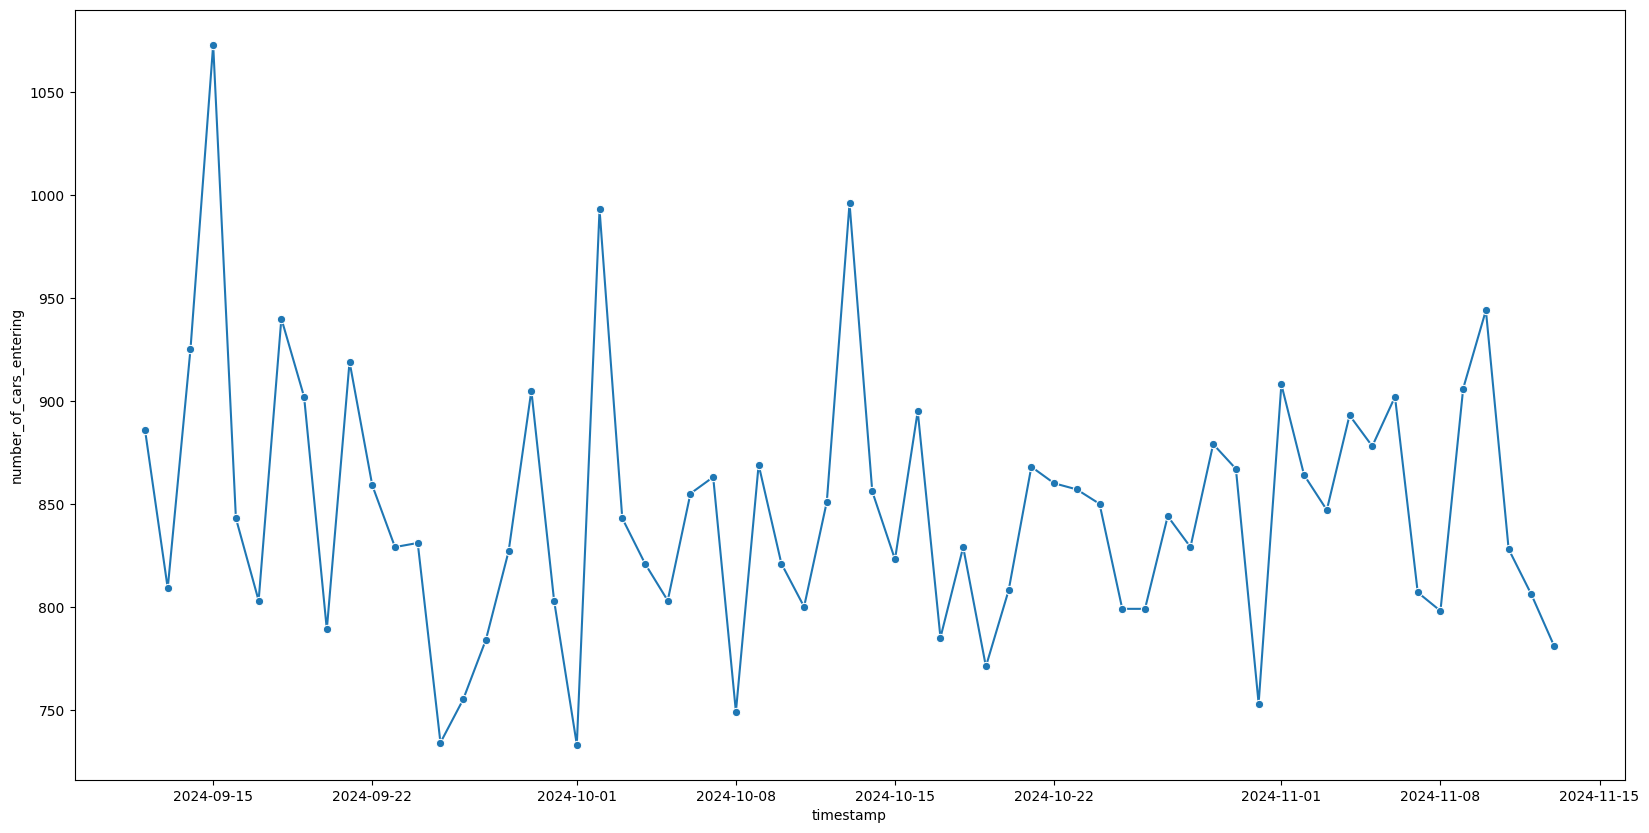

In [328]:
#plotting cars per date
plt.figure(figsize=(20, 10))
sns.lineplot(x='timestamp', y='number_of_cars_entering', data=cars_per_date, marker='o')

<Axes: xlabel='timestamp', ylabel='number_of_cars_entering'>

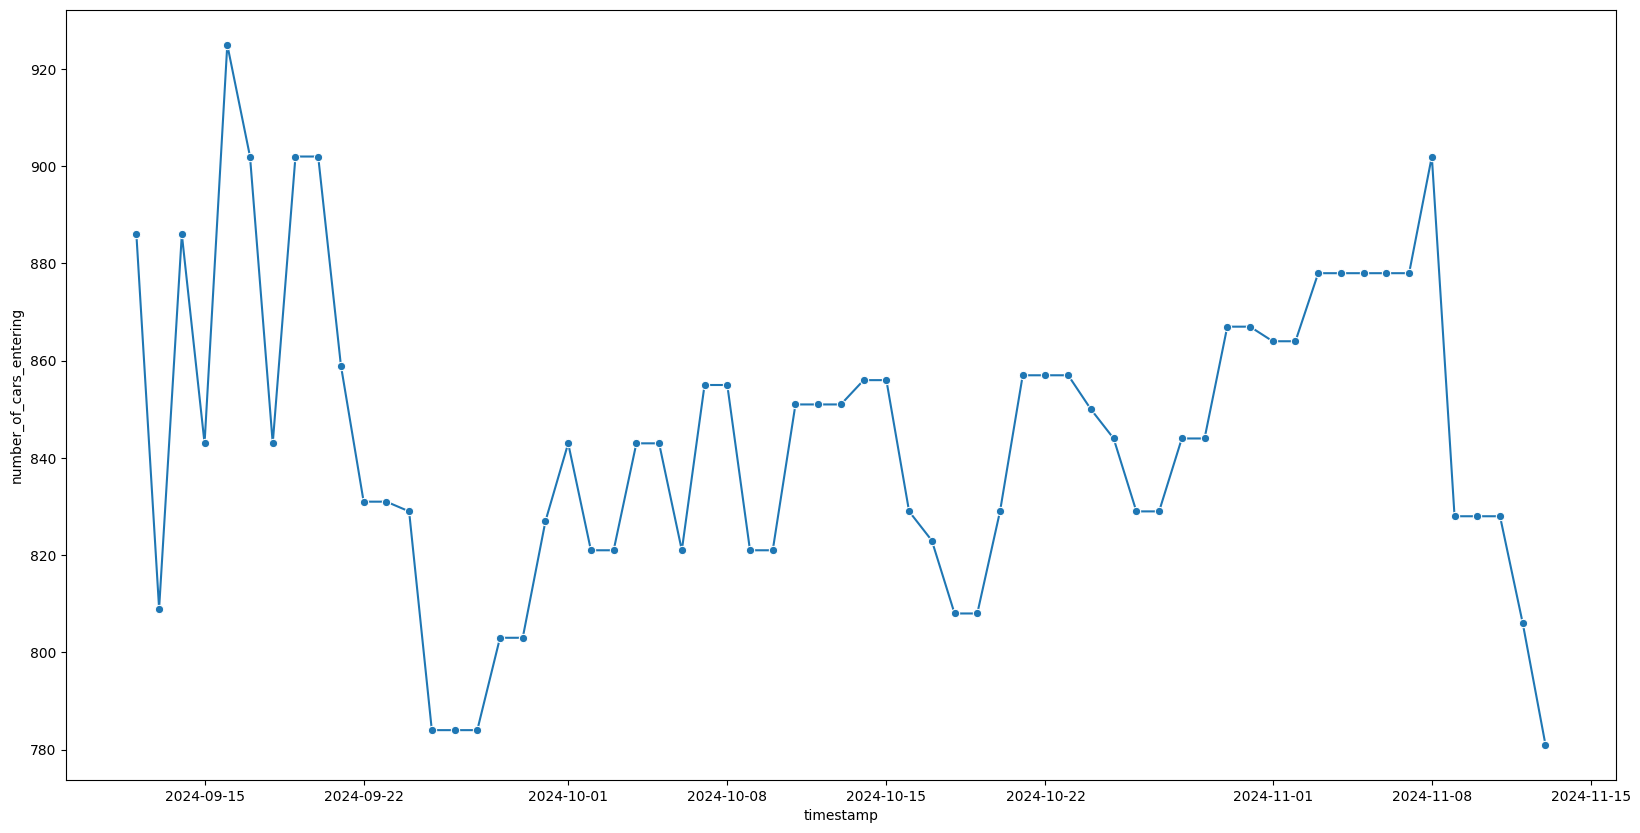

In [329]:
#plotting cars per date
plt.figure(figsize=(20, 10))
sns.lineplot(x='timestamp', y='number_of_cars_entering', data=cars_per_date_median, marker='o')

<Axes: xlabel='timestamp', ylabel='number_of_cars_entering'>

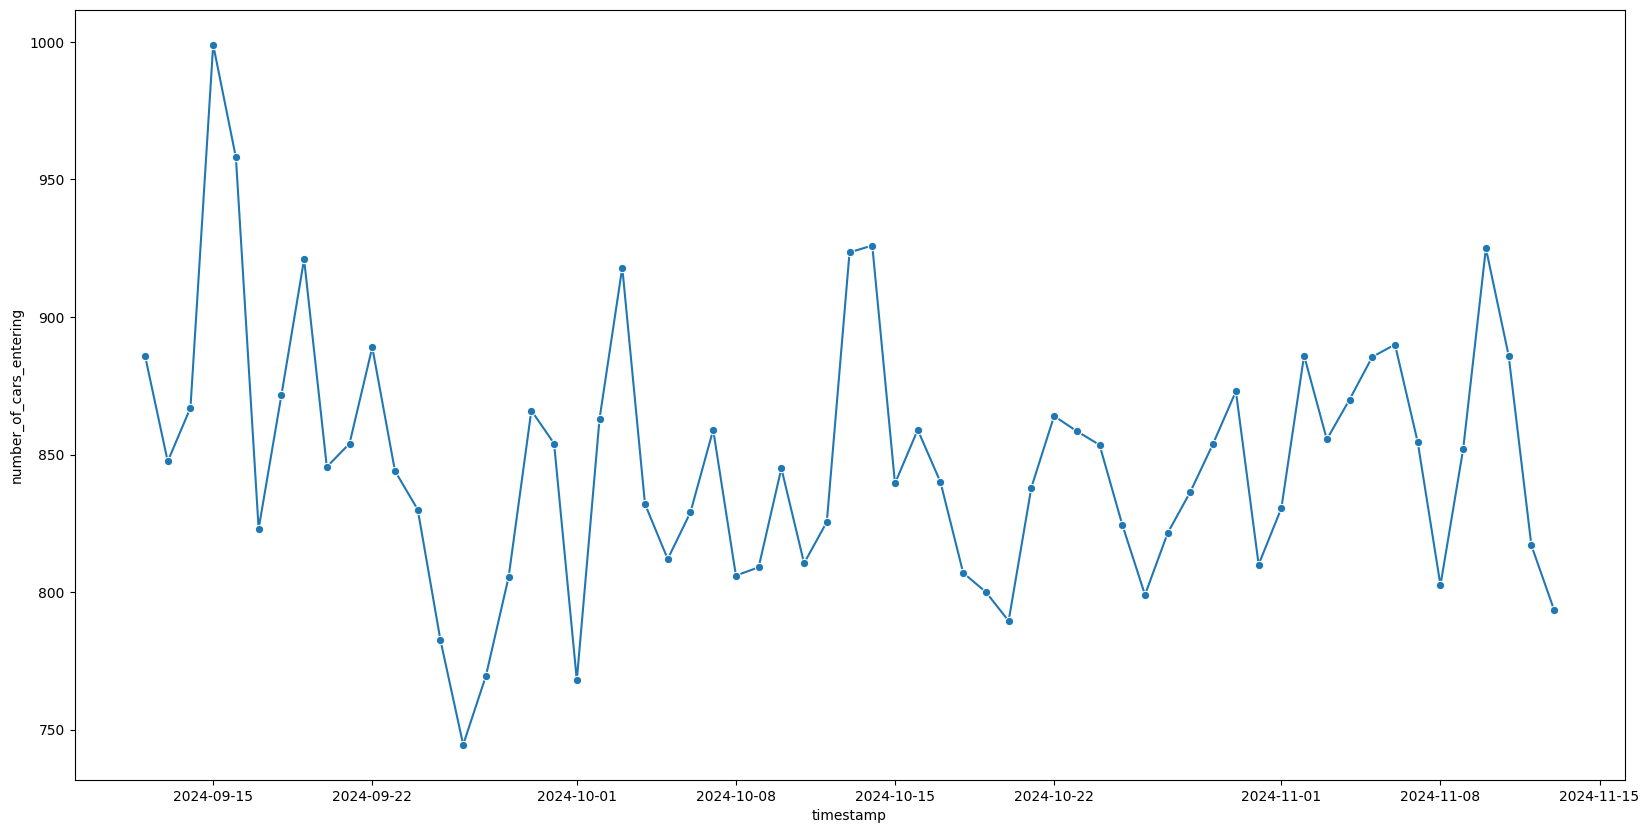

In [330]:
#plotting cars per date
plt.figure(figsize=(20, 10))
sns.lineplot(x='timestamp', y='number_of_cars_entering', data=cars_per_date_mean, marker='o')

In [331]:
# Splitting the data into training and testing sets
train_data = cars_per_date_median.iloc[:56]
test_data = cars_per_date_median.iloc[56:]

print("Training Data:")
print(train_data)
print("\nTesting Data:")
print(test_data)

Training Data:
     timestamp  number_of_cars_entering
0   2024-09-12                    886.0
1   2024-09-13                    809.0
2   2024-09-14                    886.0
3   2024-09-15                    843.0
4   2024-09-16                    925.0
5   2024-09-17                    902.0
6   2024-09-18                    843.0
7   2024-09-19                    902.0
8   2024-09-20                    902.0
9   2024-09-21                    859.0
10  2024-09-22                    831.0
11  2024-09-23                    831.0
12  2024-09-24                    829.0
13  2024-09-25                    784.0
14  2024-09-26                    784.0
15  2024-09-27                    784.0
16  2024-09-28                    803.0
17  2024-09-29                    803.0
18  2024-09-30                    827.0
19  2024-10-01                    843.0
20  2024-10-02                    821.0
21  2024-10-03                    821.0
22  2024-10-04                    843.0
23  2024-10-05           

(<Figure size 1200x800 with 3 Axes>,
 array([<Axes: ylabel='number_of_cars_entering'>,
        <Axes: title={'center': 'Autocorrelation'}>,
        <Axes: title={'center': 'Partial Autocorrelation'}>], dtype=object))

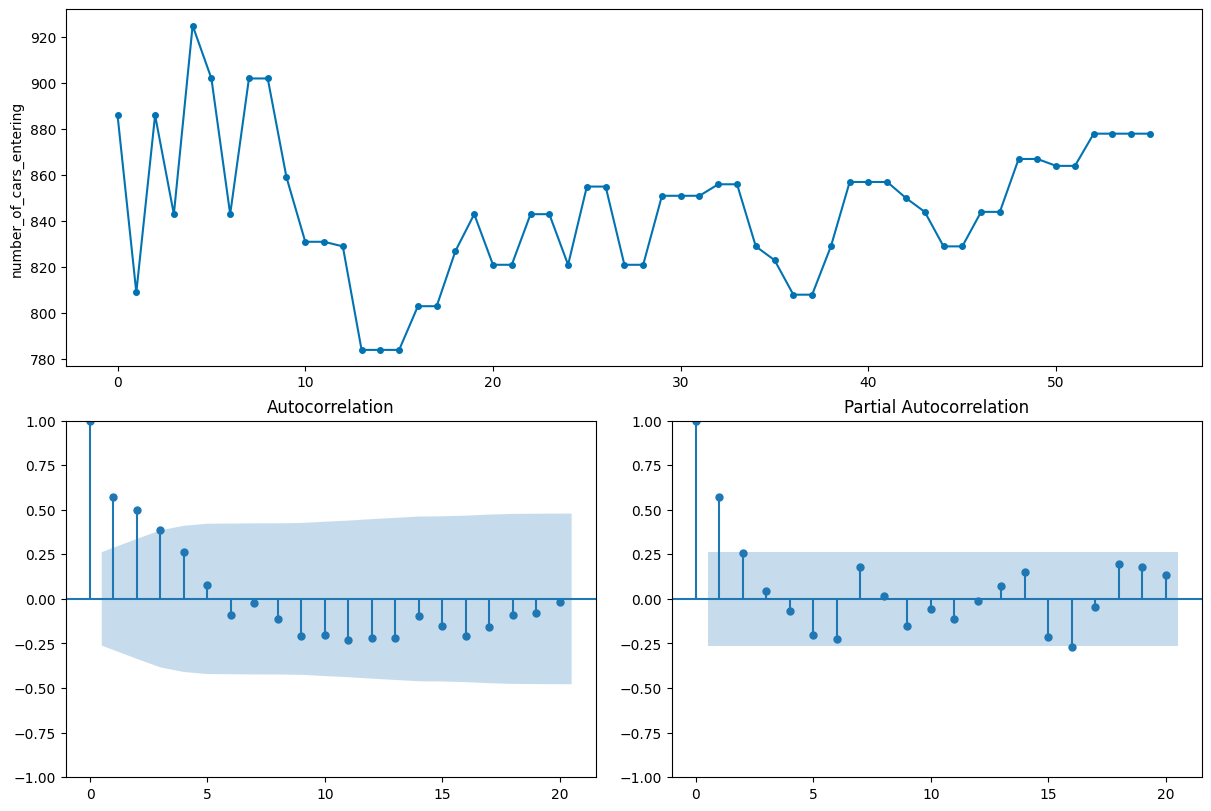

In [332]:
plot_correlations(train_data['number_of_cars_entering'], lags=20)

In [333]:
forecaster = ARIMA(order=(3, 0, 3), seasonal_order=(0, 1, 1, 14),suppress_warnings=True)
# forecaster = AutoARIMA(,suppress_warnings=True)

forecaster.fit(train_data['number_of_cars_entering'])
forecaster.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                   56
Model:             SARIMAX(3, 0, 3)x(0, 1, [1], 14)   Log Likelihood                -197.286
Date:                              Mon, 28 Oct 2024   AIC                            412.572
Time:                                      22:07:22   BIC                            428.211
Sample:                                           0   HQIC                           418.304
                                               - 56                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0920      7.116      0.013      0.990     -13.855      14.039
ar.L1          0.3467      7.250      0.048      0.962     -13.863      14.556
ar.L2          0.6985      9.674      0.072      0.942     -18.262      19.659
ar.L3         -0.5969      4.456     -0.134      0.893      -9.330       8.136
ma.L1         -0.0997     37.898     -0.003      0.998     -74.378      74.179
ma.L2         -0.0648     32.760     -0.002      0.998     -64.274      64.144
ma.L3          0.9829     71.554      0.014      0.989    -139.261     141.227
ma.S.L14      -0.1643      0.234     -0.704      0.482      -0.622       0.294
sigma2       598.8472   4.26e+04      0.014      0.989   -8.28e+04     8.4e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.27   Jarque-Bera (JB):                 2.11
Prob(Q):                              0.60   Prob(JB):                         0.35
Heteroskedasticity (H):               0.43   Skew:                            -0.54
Prob(H) (two-sided):                  0.13   Kurtosis:                         2.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

56    864.0
57    876.0
58    863.0
59    854.0
60    856.0
61    846.0
62    855.0
Name: number_of_cars_entering, dtype: float64


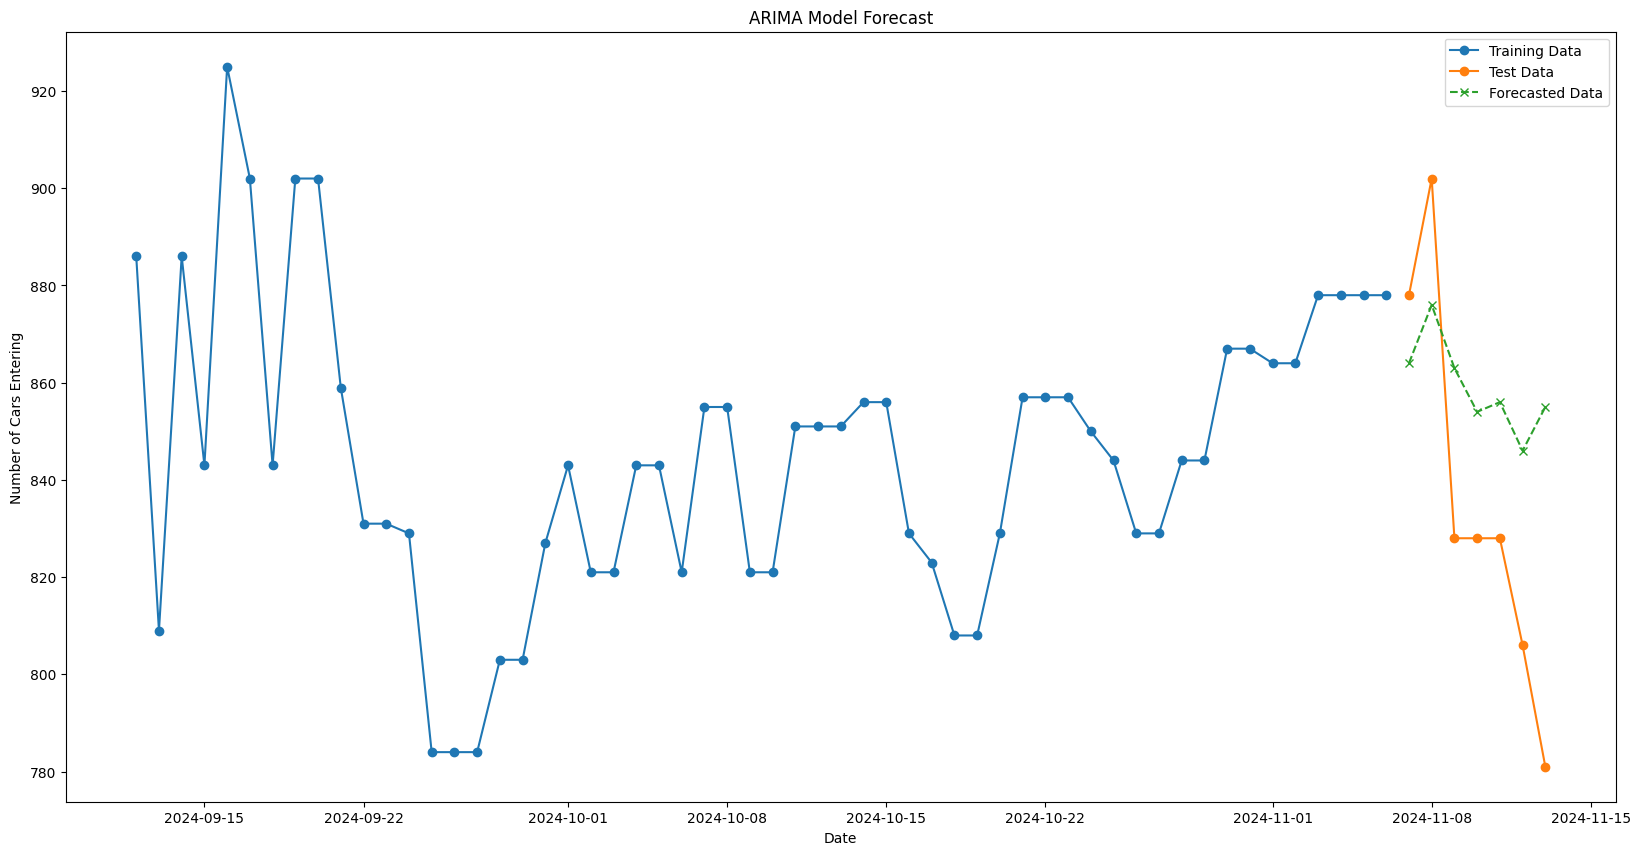

In [334]:
# Forecasting the test data

forecast = np.round(forecaster.predict(fh=[1, 2, 3, 4, 5, 6, 7]))

# print(test_data.shape[0])
print(forecast)

# print(test_data['number_of_cars_entering'])

# Plotting the training data, test data, and forecasted data
plt.figure(figsize=(20, 10))
plt.plot(train_data['timestamp'], train_data['number_of_cars_entering'], label='Training Data', marker = 'o')
plt.plot(test_data['timestamp'], test_data['number_of_cars_entering'], label='Test Data',marker = 'o')
plt.plot(test_data['timestamp'], forecast, label='Forecasted Data', linestyle='--',marker = 'x')

plt.xlabel('Date')
plt.ylabel('Number of Cars Entering')
plt.title('ARIMA Model Forecast')
plt.legend()
plt.show()

In [335]:
# Calculating the error metrics
MASE = mean_absolute_scaled_error(y_train=train_data['number_of_cars_entering'],y_true=test_data['number_of_cars_entering'], y_pred=forecast)
MAPE = mean_absolute_percentage_error(test_data['number_of_cars_entering'], forecast)

print('Mean Absolute Scaled Error:', MASE)
print('Mean Absolute Percentage Error:', MAPE)

Mean Absolute Scaled Error: 2.0182724252491697
Mean Absolute Percentage Error: 0.04237659976714747


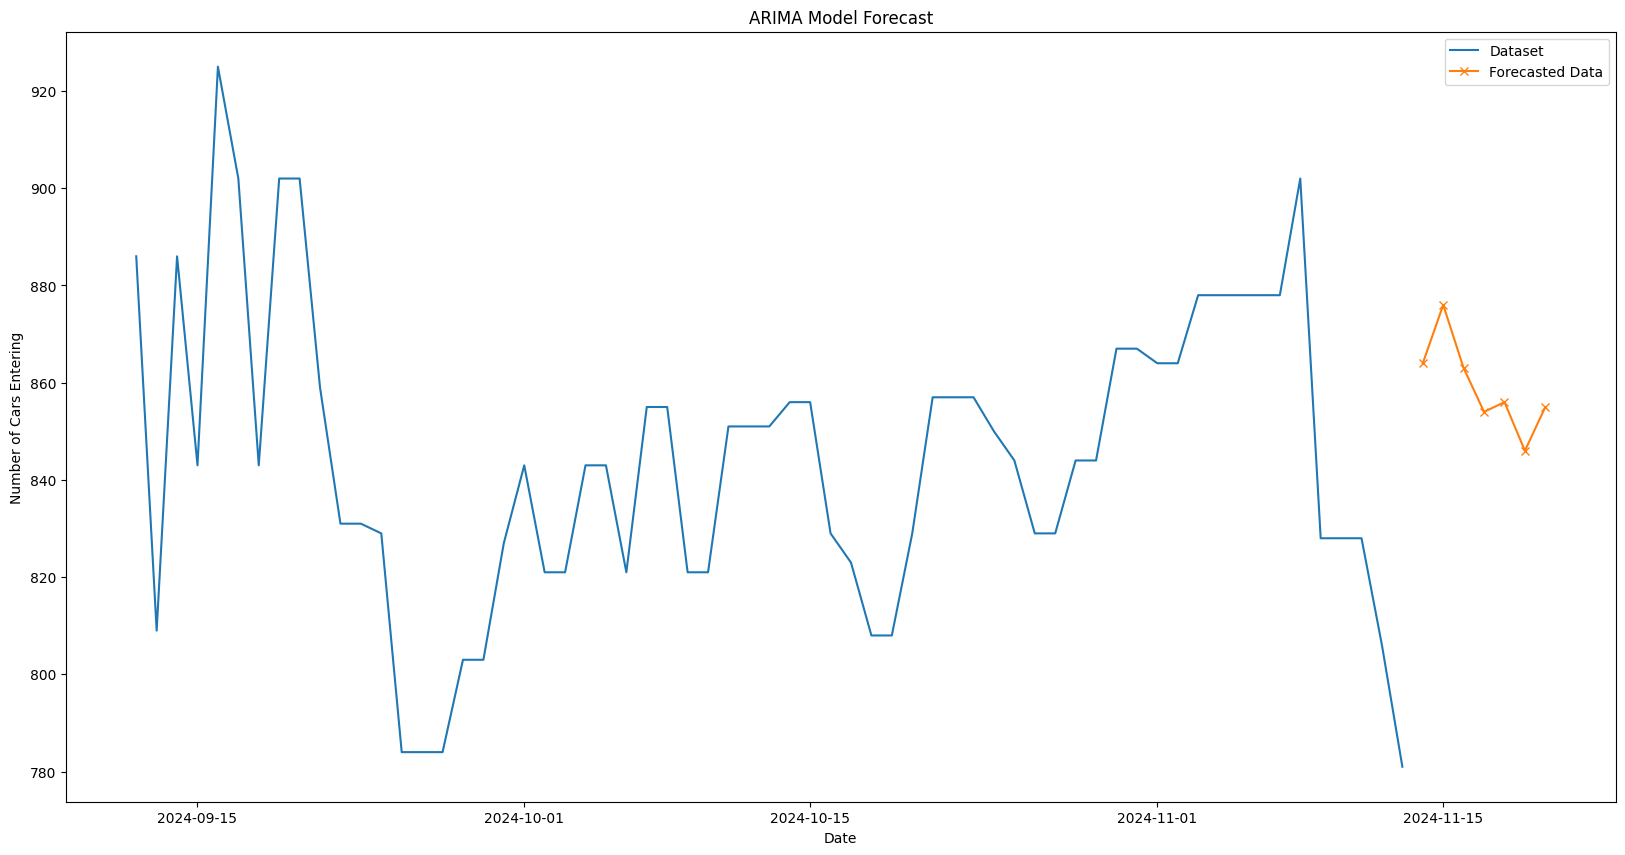

In [336]:
#forecast for the next 7 days
forecast_final = np.floor(forecaster.predict([8,9,10,11,12,13,14]))
# Create dates for the next 7 days after the last entry of cars_per_date
last_date = cars_per_date_median['timestamp'].iloc[-1]
next_7_days = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7)

# # Add the forecasted values to the dataframe
# forecast_final_df = pd.DataFrame({'timestamp': next_7_days, 'number_of_cars_entering': forecast_final})
# print(forecast_final_df)
plt.figure(figsize=(20, 10))
plt.plot(cars_per_date_median['timestamp'], cars_per_date_median['number_of_cars_entering'], label='Dataset')
plt.plot(next_7_days, forecast, label='Forecasted Data', linestyle='-',marker = 'x')

plt.xlabel('Date')
plt.ylabel('Number of Cars Entering')
plt.title('ARIMA Model Forecast')
plt.legend()
plt.show()

In [337]:
# Splitting the data into training and testing sets
train_data = cars_per_date_mean.iloc[:56]
test_data = cars_per_date_mean.iloc[56:]

print("Training Data:")
print(train_data)
print("\nTesting Data:")
print(test_data)

Training Data:
     timestamp  number_of_cars_entering
0   2024-09-12                    886.0
1   2024-09-13                    847.5
2   2024-09-14                    867.0
3   2024-09-15                    999.0
4   2024-09-16                    958.0
5   2024-09-17                    823.0
6   2024-09-18                    871.5
7   2024-09-19                    921.0
8   2024-09-20                    845.5
9   2024-09-21                    854.0
10  2024-09-22                    889.0
11  2024-09-23                    844.0
12  2024-09-24                    830.0
13  2024-09-25                    782.5
14  2024-09-26                    744.5
15  2024-09-27                    769.5
16  2024-09-28                    805.5
17  2024-09-29                    866.0
18  2024-09-30                    854.0
19  2024-10-01                    768.0
20  2024-10-02                    863.0
21  2024-10-03                    918.0
22  2024-10-04                    832.0
23  2024-10-05           

(<Figure size 1200x800 with 3 Axes>,
 array([<Axes: ylabel='number_of_cars_entering'>,
        <Axes: title={'center': 'Autocorrelation'}>,
        <Axes: title={'center': 'Partial Autocorrelation'}>], dtype=object))

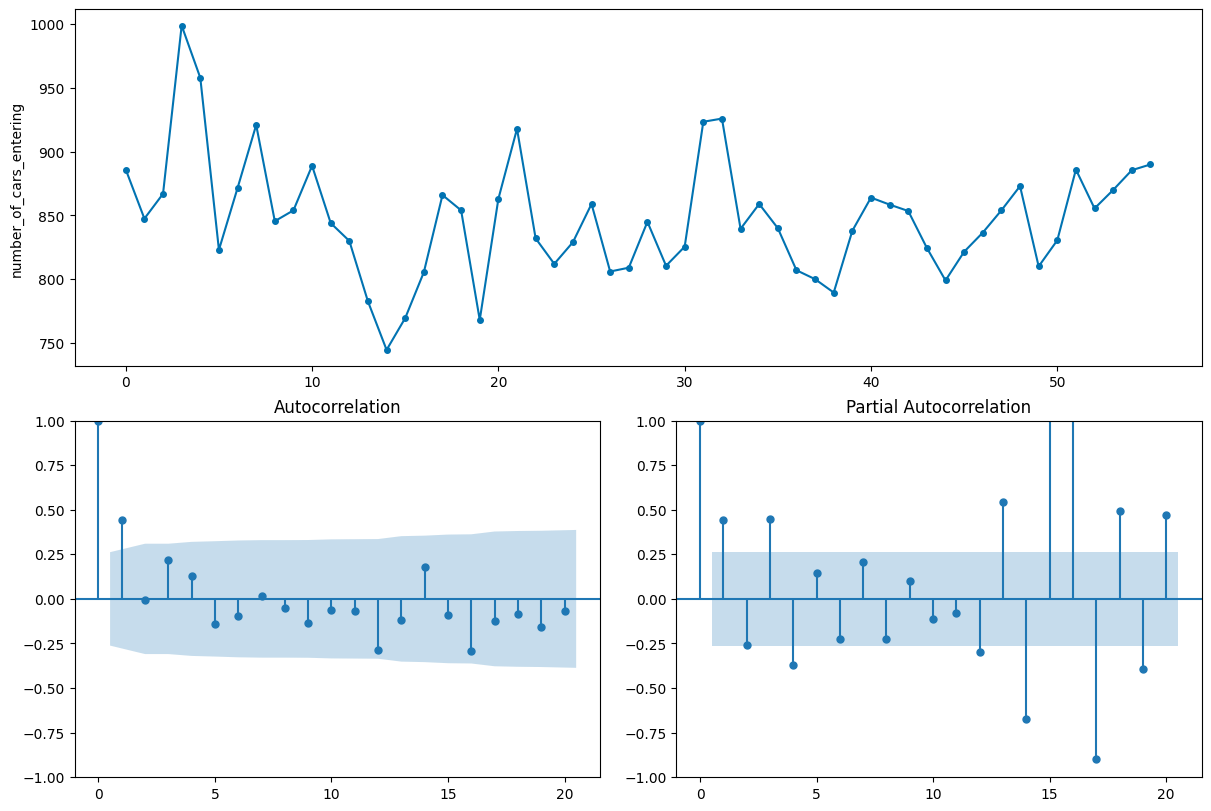

In [338]:
plot_correlations(train_data['number_of_cars_entering'], lags=20)

In [339]:
forecaster = ARIMA(order=(3, 0, 3), seasonal_order=(0, 1, 1, 14),suppress_warnings=True)
# forecaster = AutoARIMA(,suppress_warnings=True)

forecaster.fit(train_data['number_of_cars_entering'])
forecaster.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                   56
Model:             SARIMAX(3, 0, 3)x(0, 1, [1], 14)   Log Likelihood                -208.004
Date:                              Mon, 28 Oct 2024   AIC                            434.008
Time:                                      22:07:25   BIC                            449.647
Sample:                                           0   HQIC                           439.741
                                               - 56                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -2.9718      9.665     -0.307      0.758     -21.915      15.972
ar.L1          1.0431      0.205      5.079      0.000       0.641       1.446
ar.L2         -1.0170      0.228     -4.460      0.000      -1.464      -0.570
ar.L3          0.2542      0.180      1.414      0.157      -0.098       0.607
ma.L1          0.0932      8.462      0.011      0.991     -16.492      16.679
ma.L2          0.0917      8.523      0.011      0.991     -16.613      16.796
ma.L3          0.9985      0.324      3.083      0.002       0.364       1.633
ma.S.L14      -0.4244      0.271     -1.564      0.118      -0.956       0.107
sigma2       946.4985      0.017   5.55e+04      0.000     946.465     946.532
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):                 0.43
Prob(Q):                              0.78   Prob(JB):                         0.81
Heteroskedasticity (H):               0.48   Skew:                            -0.19
Prob(H) (two-sided):                  0.19   Kurtosis:                         2.69
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 5.49e+21. Standard errors may be unstable.
"""

56    878.0
57    825.0
58    811.0
59    859.0
60    861.0
61    830.0
62    861.0
Name: number_of_cars_entering, dtype: float64


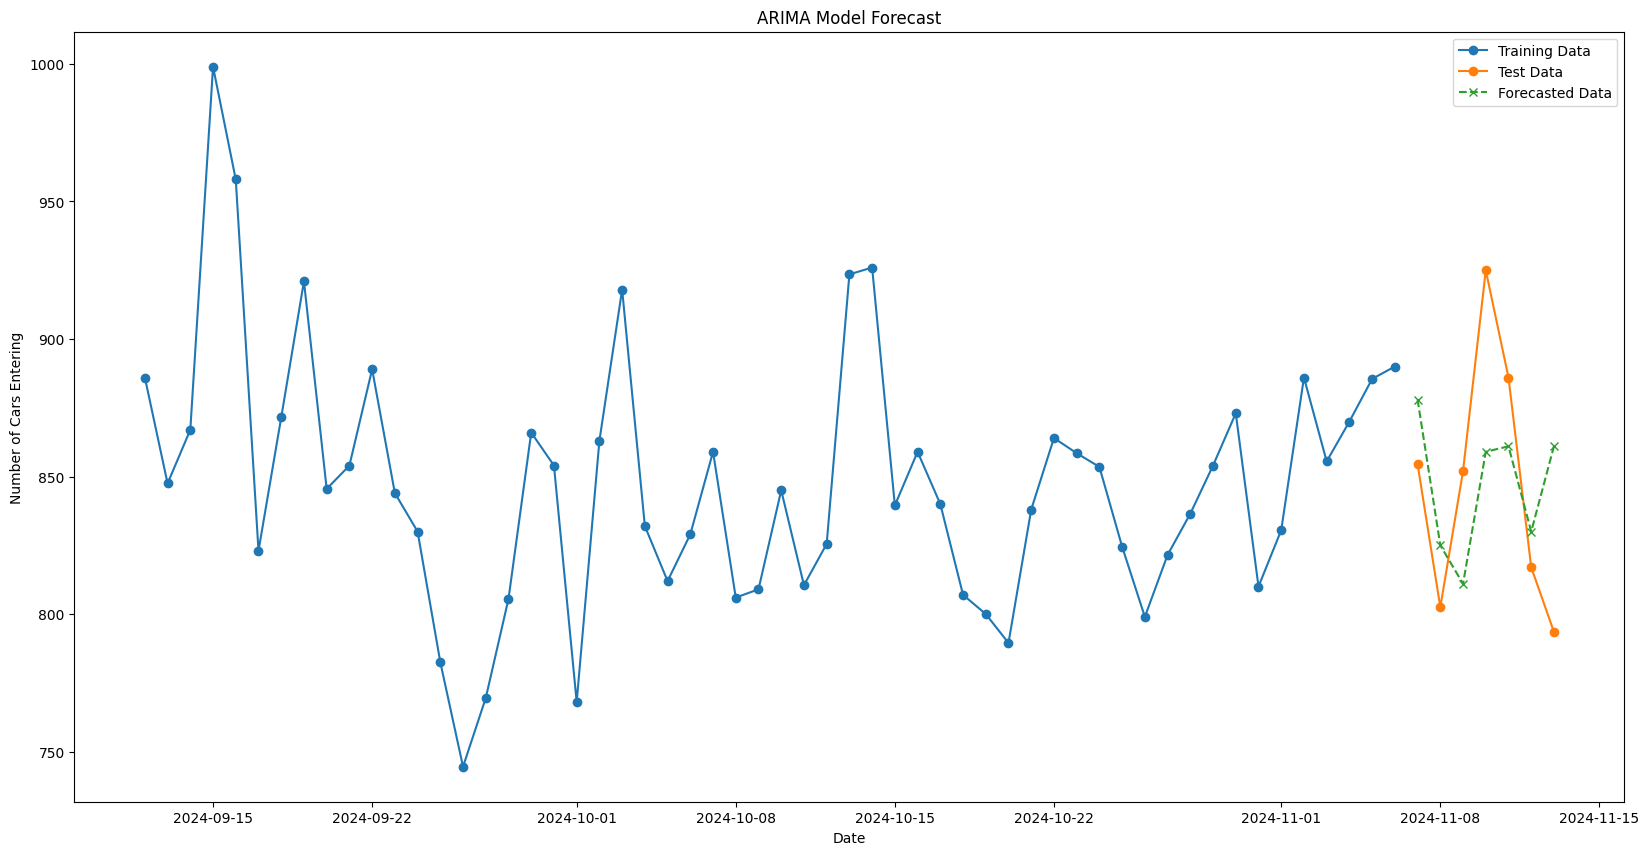

In [340]:
# Forecasting the test data

forecast = np.round(forecaster.predict(fh=[1, 2 ,3 , 4, 5, 6, 7]))

# print(test_data.shape[0])
print(forecast)

# print(test_data['number_of_cars_entering'])

# Plotting the training data, test data, and forecasted data
plt.figure(figsize=(20, 10))
plt.plot(train_data['timestamp'], train_data['number_of_cars_entering'], label='Training Data', marker = 'o')
plt.plot(test_data['timestamp'], test_data['number_of_cars_entering'], label='Test Data',marker = 'o')
plt.plot(test_data['timestamp'], forecast, label='Forecasted Data', linestyle='--',marker = 'x')

plt.xlabel('Date')
plt.ylabel('Number of Cars Entering')
plt.title('ARIMA Model Forecast')
plt.legend()
plt.show()

In [341]:
# Calculating the error metrics
MASE = mean_absolute_scaled_error(y_train=train_data['number_of_cars_entering'],y_true=test_data['number_of_cars_entering'], y_pred=forecast)
MAPE = mean_absolute_percentage_error(test_data['number_of_cars_entering'], forecast)

print('Mean Absolute Scaled Error:', MASE)
print('Mean Absolute Percentage Error:', MAPE)

Mean Absolute Scaled Error: 0.9741349777321001
Mean Absolute Percentage Error: 0.04345814323789073


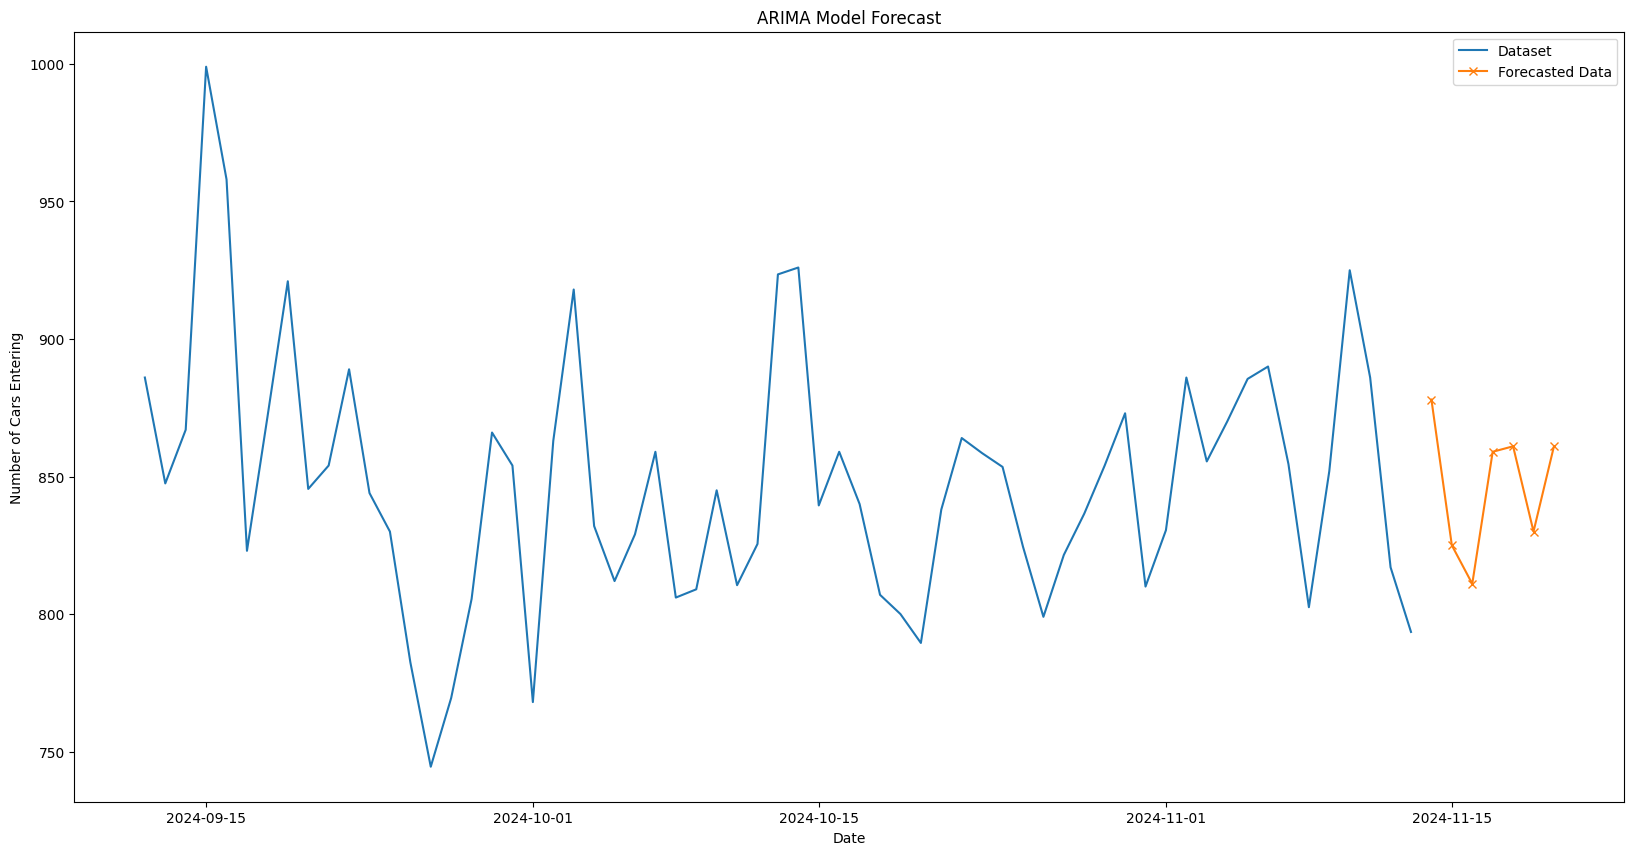

: 

In [342]:
#forecast for the next 7 days
forecast_final = np.floor(forecaster.predict([8,9,10,11,12,13,14]))
# Create dates for the next 7 days after the last entry of cars_per_date
last_date = cars_per_date_mean['timestamp'].iloc[-1]
next_7_days = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7)

# # Add the forecasted values to the dataframe
# forecast_final_df = pd.DataFrame({'timestamp': next_7_days, 'number_of_cars_entering': forecast_final})
# print(forecast_final_df)
plt.figure(figsize=(20, 10))
plt.plot(cars_per_date_mean['timestamp'], cars_per_date_mean['number_of_cars_entering'], label='Dataset')
plt.plot(next_7_days, forecast, label='Forecasted Data', linestyle='-',marker = 'x')

plt.xlabel('Date')
plt.ylabel('Number of Cars Entering')
plt.title('ARIMA Model Forecast')
plt.legend()
plt.show()